# Salience Trend Audit

This notebook analyses annual source-year Salience from the completed Common Crawl trend run. Following the project design, the primary measure is WARC-validated target hits per million minimum-length WET tokens. ADHD and Autism are aggregated as conceptual target groups; `frustration`, `loneliness`, and `sadness` remain separate comparator series.

Candidate and WET-validated rates, WARC-over-WET retention, raw target forms, and publication-year status are retained as diagnostics. The trend run does not contain domain-concentration or frame-classification outputs, so those planned diagnostics remain unavailable here.

## Setup

The input contract is restricted to the two processed trend outputs. Tables are written to the ignored processed-analysis directory; report-ready figures are exported as PNG and PDF.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "05_salience":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

TREND_DIR = PROJECT_ROOT / "data/processed/trend"
TREND_RATES_PATH = TREND_DIR / "trend_rates.csv"
PUBLICATION_DIAGNOSTICS_PATH = TREND_DIR / "trend_publication_year_diagnostics.csv"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/lsc/salience"
FIGURE_DIR = PROJECT_ROOT / "reports/figures/lsc/salience"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_YEARS = list(range(2014, 2027))
EARLY_YEARS = [2014, 2015, 2016]
LATE_YEARS = [2024, 2025, 2026]
TARGET_UNITS = ["ADHD", "Autism"]
BASELINE_UNITS = ["frustration", "loneliness", "sadness"]
ANALYSIS_UNITS = TARGET_UNITS + BASELINE_UNITS

COLOURS = {
    "ADHD": "#0072B2",
    "Autism": "#D55E00",
    "frustration": "#009E73",
    "loneliness": "#CC79A7",
    "sadness": "#6E6E6E",
}
MARKERS = {"ADHD": "o", "Autism": "s", "frustration": "^", "loneliness": "D", "sadness": "v"}

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

def save_figure(figure: plt.Figure, stem: str) -> None:
    figure.savefig(FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

for path in [TREND_RATES_PATH, PUBLICATION_DIAGNOSTICS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required trend output: {path.relative_to(PROJECT_ROOT)}")

## Load and Audit the Trend Contract

The audit checks annual coverage, denominator consistency, validation-stage ordering, and whether matched target forms sum exactly to their target-group totals. A fixed domain cap was applied during collection, but domain-level counts are not present in the processed trend handoff.

In [2]:
trend_rates = pd.read_csv(TREND_RATES_PATH)
publication_diagnostics = pd.read_csv(PUBLICATION_DIAGNOSTICS_PATH)

required_rate_columns = {
    "year", "source_year", "temporal_axis", "primary_denominator", "aggregation_level",
    "term_role", "term_group", "matched_term", "tokens_minlen", "candidate_hits",
    "validated_hits_wet", "validated_hits_warc", "candidate_hits_per_million_minlen_tokens",
    "wet_salience_per_million_minlen_tokens", "primary_salience_per_million_tokens",
    "warc_over_wet_validation_rate", "pct_warc_validated_docs_with_published_ts",
}
missing_rate_columns = sorted(required_rate_columns - set(trend_rates.columns))
if missing_rate_columns:
    raise ValueError(f"Missing trend-rate columns: {missing_rate_columns}")

all_rows = trend_rates.loc[trend_rates["aggregation_level"].eq("all")].copy()
matched_target_rows = trend_rates.loc[
    trend_rates["aggregation_level"].eq("matched_term") & trend_rates["term_role"].eq("target")
].copy()
target_group_rows = trend_rates.loc[
    trend_rates["aggregation_level"].eq("term_group") & trend_rates["term_role"].eq("target")
].copy()

raw_form_sums = matched_target_rows.groupby(["year", "term_group"], as_index=False)[
    ["candidate_hits", "validated_hits_wet", "validated_hits_warc"]
].sum()
group_counts = target_group_rows[["year", "term_group", "candidate_hits", "validated_hits_wet", "validated_hits_warc"]]
sum_check = group_counts.merge(raw_form_sums, on=["year", "term_group"], suffixes=("_group", "_raw_sum"))
sum_check_ok = all(
    np.allclose(sum_check[f"{column}_group"], sum_check[f"{column}_raw_sum"])
    for column in ["candidate_hits", "validated_hits_wet", "validated_hits_warc"]
)

checks = pd.DataFrame([
    {"check": "expected_source_years", "status": "pass" if sorted(trend_rates["year"].unique()) == EXPECTED_YEARS else "fail", "detail": str([int(year) for year in sorted(trend_rates["year"].unique())])},
    {"check": "source_year_axis", "status": "pass" if set(trend_rates["temporal_axis"]) == {"source_year"} else "fail", "detail": str(sorted(trend_rates["temporal_axis"].unique()))},
    {"check": "minimum_length_token_denominator", "status": "pass" if set(trend_rates["primary_denominator"]) == {"tokens_minlen"} else "fail", "detail": str(sorted(trend_rates["primary_denominator"].unique()))},
    {"check": "validation_counts_monotonic", "status": "pass" if ((trend_rates["candidate_hits"] >= trend_rates["validated_hits_wet"]) & (trend_rates["validated_hits_wet"] >= trend_rates["validated_hits_warc"])).all() else "fail", "detail": "candidate >= WET validated >= WARC validated"},
    {"check": "raw_forms_sum_to_target_groups", "status": "pass" if sum_check_ok else "fail", "detail": "matched target forms reproduce group-level counts"},
    {"check": "publication_timestamp_coverage", "status": "pass" if all_rows["pct_warc_validated_docs_with_published_ts"].min() >= 95 else "warn", "detail": f"minimum={all_rows['pct_warc_validated_docs_with_published_ts'].min():.2f}%"},
    {"check": "domain_concentration", "status": "not_available", "detail": "processed trend handoff has no domain-level counts; fixed collection domain cap=50 still applies"},
    {"check": "frame_composition", "status": "not_available", "detail": "requires completed frame classifier"},
])
checks.to_csv(OUTPUT_DIR / "salience_audit_checks.csv", index=False)

denominator_audit = all_rows[[
    "year", "docs_scanned", "docs_minlen", "tokens_scanned", "tokens_minlen",
    "candidate_hits", "validated_hits_wet", "validated_hits_warc",
    "pct_fetch_success_docs_with_published_ts", "pct_warc_validated_docs_with_published_ts",
]].copy()
denominator_audit.to_csv(OUTPUT_DIR / "salience_denominator_audit.csv", index=False)

display(checks)
display(denominator_audit)

,check,status,detail
0,expected_source_years,pass,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202..."
1,source_year_axis,pass,['source_year']
2,minimum_length_token_denominator,pass,['tokens_minlen']
3,validation_counts_monotonic,pass,candidate >= WET validated >= WARC validated
4,raw_forms_sum_to_target_groups,pass,matched target forms reproduce group-level counts
5,publication_timestamp_coverage,pass,minimum=96.06%
6,domain_concentration,not_available,processed trend handoff has no domain-level co...
7,frame_composition,not_available,requires completed frame classifier


,year,docs_scanned,docs_minlen,tokens_scanned,tokens_minlen,candidate_hits,validated_hits_wet,validated_hits_warc,pct_fetch_success_docs_with_published_ts,pct_warc_validated_docs_with_published_ts
0,2014,5349060.0,3762398.0,3.483619e+09,3.439498e+09,57128.0,29182.0,13918.0,98.051083,97.347595
15,2015,5291648.0,3632797.0,3.470904e+09,3.426098e+09,49619.0,25203.0,11898.0,98.064335,97.077497
30,2016,5760599.0,5329183.0,5.722869e+09,5.709595e+09,85600.0,40044.0,19945.0,98.426011,97.575085
45,2017,4435233.0,4231720.0,4.633506e+09,4.626729e+09,51233.0,25351.0,11828.0,98.033668,97.200861
60,2018,4702862.0,4429927.0,4.326587e+09,4.316886e+09,45638.0,26406.0,12086.0,98.229411,97.506285
75,2019,4377625.0,4099485.0,4.100525e+09,4.091312e+09,42410.0,28262.0,13847.0,97.190097,96.059658
90,2020,5040987.0,4785776.0,5.392948e+09,5.383636e+09,53444.0,32802.0,14117.0,97.900670,97.359794
105,2021,4818457.0,4556751.0,4.847258e+09,4.837622e+09,46689.0,30804.0,13996.0,98.260558,98.121324
120,2022,4217647.0,3870995.0,4.027739e+09,4.017628e+09,39809.0,26183.0,11948.0,98.552681,98.307159
135,2023,3806981.0,3525612.0,3.585727e+09,3.577251e+09,33691.0,21098.0,10102.0,98.573417,98.445847


## Construct Main Analysis Units

The main table uses target-group totals for ADHD and Autism and matched-term totals for each comparator. `relative_to_2014` supports shape comparison but does not replace the absolute per-million-token Salience measure.

In [3]:
target_units = target_group_rows.copy()
target_units["analysis_unit"] = target_units["term_group"].map({"adhd": "ADHD", "autism": "Autism"})

baseline_units = trend_rates.loc[
    trend_rates["aggregation_level"].eq("matched_term") & trend_rates["term_role"].eq("baseline")
].copy()
baseline_units["analysis_unit"] = baseline_units["matched_term"]

unit_year = pd.concat([target_units, baseline_units], ignore_index=True)
unit_year = unit_year.loc[unit_year["analysis_unit"].isin(ANALYSIS_UNITS)].copy()
unit_year["analysis_role"] = np.where(unit_year["analysis_unit"].isin(TARGET_UNITS), "target", "baseline")
unit_year = unit_year.sort_values(["analysis_role", "analysis_unit", "year"]).reset_index(drop=True)
unit_year["wet_over_candidate_validation_rate"] = unit_year["validated_hits_wet"] / unit_year["candidate_hits"]
unit_year["relative_to_2014"] = unit_year["primary_salience_per_million_tokens"] / unit_year.groupby("analysis_unit")["primary_salience_per_million_tokens"].transform("first")

main_columns = [
    "year", "source_year", "analysis_role", "analysis_unit", "tokens_minlen",
    "candidate_hits", "validated_hits_wet", "validated_hits_warc",
    "candidate_hits_per_million_minlen_tokens", "wet_salience_per_million_minlen_tokens",
    "primary_salience_per_million_tokens", "relative_to_2014",
    "wet_over_candidate_validation_rate", "warc_over_wet_validation_rate",
    "pct_warc_validated_docs_with_published_ts",
]
unit_year = unit_year[main_columns]
unit_year.to_csv(OUTPUT_DIR / "salience_unit_year.csv", index=False)

if unit_year.groupby("analysis_unit")["year"].nunique().ne(len(EXPECTED_YEARS)).any():
    raise ValueError("At least one main analysis unit lacks a complete annual series.")

display(unit_year.head(15))

,year,source_year,analysis_role,analysis_unit,tokens_minlen,candidate_hits,validated_hits_wet,validated_hits_warc,candidate_hits_per_million_minlen_tokens,wet_salience_per_million_minlen_tokens,primary_salience_per_million_tokens,relative_to_2014,wet_over_candidate_validation_rate,warc_over_wet_validation_rate,pct_warc_validated_docs_with_published_ts
0,2014,2014,baseline,frustration,3.439498e+09,12759.0,8080.0,5079.0,3.709553,2.349180,1.476669,1.000000,0.633278,0.628589,97.347595
1,2015,2015,baseline,frustration,3.426098e+09,11776.0,7292.0,4481.0,3.437146,2.128369,1.307902,0.885711,0.619226,0.614509,97.077497
2,2016,2016,baseline,frustration,5.709595e+09,19410.0,12381.0,7935.0,3.399540,2.168455,1.389766,0.941149,0.637867,0.640901,97.575085
3,2017,2017,baseline,frustration,4.626729e+09,11601.0,6232.0,3947.0,2.507387,1.346956,0.853087,0.577710,0.537195,0.633344,97.200861
4,2018,2018,baseline,frustration,4.316886e+09,9951.0,6045.0,3967.0,2.305134,1.400315,0.918949,0.622312,0.607477,0.656245,97.506285
5,2019,2019,baseline,frustration,4.091312e+09,8863.0,6270.0,4137.0,2.166298,1.532516,1.011167,0.684762,0.707435,0.659809,96.059658
6,2020,2020,baseline,frustration,5.383636e+09,11735.0,7519.0,4444.0,2.179754,1.396640,0.825464,0.559004,0.640733,0.591036,97.359794
7,2021,2021,baseline,frustration,4.837622e+09,9928.0,7269.0,4537.0,2.052248,1.502598,0.937857,0.635117,0.732172,0.624157,98.121324
8,2022,2022,baseline,frustration,4.017628e+09,8282.0,6071.0,3881.0,2.061415,1.511090,0.965993,0.654170,0.733035,0.639269,98.307159
9,2023,2023,baseline,frustration,3.577251e+09,6796.0,4815.0,3410.0,1.899783,1.346006,0.953246,0.645538,0.708505,0.708204,98.445847


## Descriptive Trend Summary

The summary compares 2014–2016 with 2024–2026, estimates a simple linear slope across source years, and records rank-order direction. These are descriptive trajectory summaries, not confirmatory time-series inference.

In [4]:
summary_rows = []
for analysis_unit, frame in unit_year.groupby("analysis_unit", sort=False):
    frame = frame.sort_values("year")
    early_mean = frame.loc[frame["year"].isin(EARLY_YEARS), "primary_salience_per_million_tokens"].mean()
    late_mean = frame.loc[frame["year"].isin(LATE_YEARS), "primary_salience_per_million_tokens"].mean()
    slope = np.polyfit(frame["year"], frame["primary_salience_per_million_tokens"], 1)[0]
    summary_rows.append({
        "analysis_unit": analysis_unit,
        "analysis_role": frame["analysis_role"].iloc[0],
        "early_2014_2016_mean": early_mean,
        "late_2024_2026_mean": late_mean,
        "early_to_late_pct_change": 100 * (late_mean / early_mean - 1),
        "linear_slope_per_year": slope,
        "spearman_year_rate": frame["year"].corr(frame["primary_salience_per_million_tokens"], method="spearman"),
        "minimum_primary_salience": frame["primary_salience_per_million_tokens"].min(),
        "maximum_primary_salience": frame["primary_salience_per_million_tokens"].max(),
        "mean_warc_over_wet_validation_rate": frame["warc_over_wet_validation_rate"].mean(),
        "minimum_warc_over_wet_validation_rate": frame["warc_over_wet_validation_rate"].min(),
        "maximum_warc_over_wet_validation_rate": frame["warc_over_wet_validation_rate"].max(),
        "wet_warc_rate_correlation": frame["wet_salience_per_million_minlen_tokens"].corr(frame["primary_salience_per_million_tokens"]),
    })

trend_summary = pd.DataFrame(summary_rows)
trend_summary.to_csv(OUTPUT_DIR / "salience_trend_summary.csv", index=False)
display(trend_summary.round(4))

,analysis_unit,analysis_role,early_2014_2016_mean,late_2024_2026_mean,early_to_late_pct_change,linear_slope_per_year,spearman_year_rate,minimum_primary_salience,maximum_primary_salience,mean_warc_over_wet_validation_rate,minimum_warc_over_wet_validation_rate,maximum_warc_over_wet_validation_rate,wet_warc_rate_correlation
0,frustration,baseline,1.3914,1.1345,-18.4654,-0.0175,-0.0879,0.8255,1.4767,0.6630,0.5910,0.7765,0.9265
1,loneliness,baseline,0.3031,0.3477,14.7130,0.0056,0.6429,0.2566,0.3713,0.5423,0.4905,0.6163,0.8000
2,sadness,baseline,0.6515,0.4441,-31.8274,-0.0171,-0.7418,0.4177,0.6841,0.5922,0.5175,0.7045,0.9094
3,ADHD,target,0.3429,0.4113,19.9636,0.0073,0.4615,0.2808,0.4698,0.3215,0.2889,0.3603,0.9472
4,Autism,target,0.9819,0.7453,-24.0988,-0.0228,-0.5604,0.6808,1.1409,0.3618,0.3374,0.4187,0.9360


## Primary Salience Trajectories

Absolute rates are separated into target and comparator panels because their scales differ. The indexed panel compares trajectory shape relative to each unit's 2014 rate.

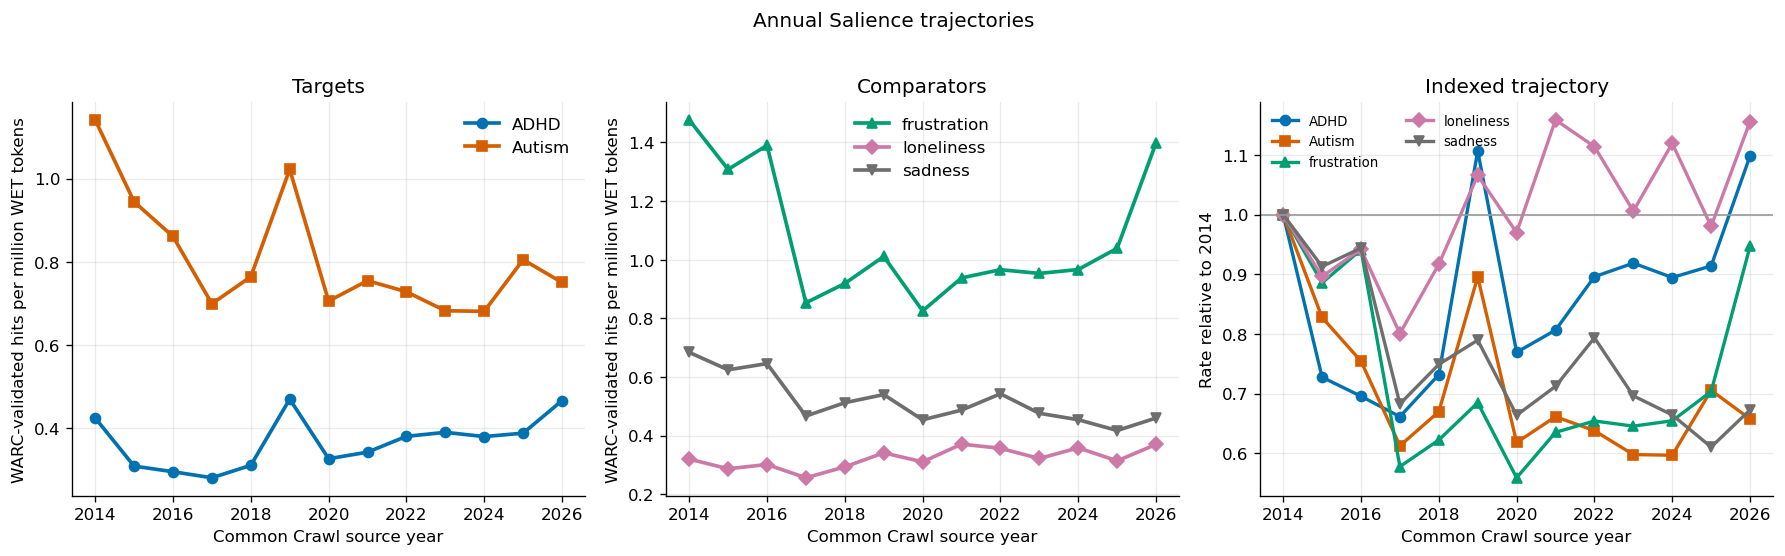

In [5]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, units, title in zip(axes[:2], [TARGET_UNITS, BASELINE_UNITS], ["Targets", "Comparators"]):
    for unit in units:
        frame = unit_year.loc[unit_year["analysis_unit"].eq(unit)]
        axis.plot(frame["year"], frame["primary_salience_per_million_tokens"], color=COLOURS[unit], marker=MARKERS[unit], linewidth=2.2, label=unit)
    axis.set_title(title)
    axis.set_ylabel("WARC-validated hits per million WET tokens")
    axis.set_xticks(EXPECTED_YEARS[::2])
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)

for unit in ANALYSIS_UNITS:
    frame = unit_year.loc[unit_year["analysis_unit"].eq(unit)]
    axes[2].plot(frame["year"], frame["relative_to_2014"], color=COLOURS[unit], marker=MARKERS[unit], linewidth=2.0, label=unit)
axes[2].axhline(1, color="#999999", linewidth=1)
axes[2].set_title("Indexed trajectory")
axes[2].set_ylabel("Rate relative to 2014")
axes[2].set_xticks(EXPECTED_YEARS[::2])
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False, fontsize=8, ncol=2)

for axis in axes:
    axis.set_xlabel("Common Crawl source year")
figure.suptitle("Annual Salience trajectories", y=1.02)
figure.tight_layout()
save_figure(figure, "lsc_salience_primary_trajectories")
plt.show()

## Validation-Stage and Retention Diagnostics

Candidate, WET-validated, and WARC-validated target rates are plotted together to show how filtering changes the observed trajectory. Retention is a pipeline diagnostic, not a substantive Salience outcome.

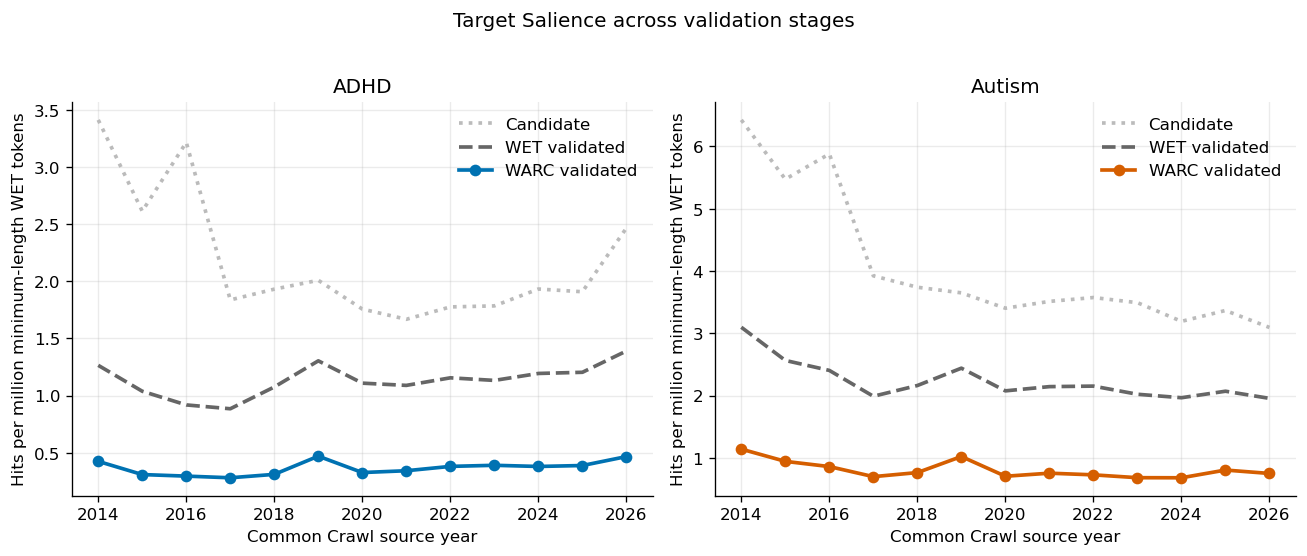

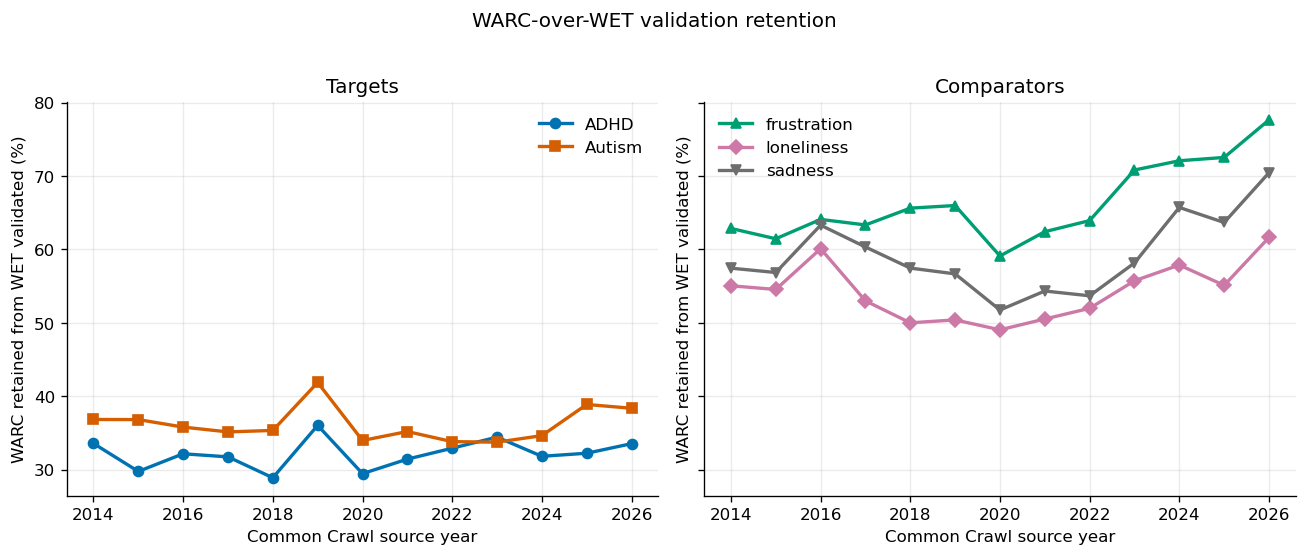

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
stage_columns = [
    ("candidate_hits_per_million_minlen_tokens", "Candidate", "#BBBBBB", ":"),
    ("wet_salience_per_million_minlen_tokens", "WET validated", "#666666", "--"),
    ("primary_salience_per_million_tokens", "WARC validated", None, "-"),
]
for axis, unit in zip(axes, TARGET_UNITS):
    frame = unit_year.loc[unit_year["analysis_unit"].eq(unit)]
    for column, label, colour, linestyle in stage_columns:
        axis.plot(frame["year"], frame[column], color=colour or COLOURS[unit], linewidth=2.2, linestyle=linestyle, marker="o" if label == "WARC validated" else None, label=label)
    axis.set_title(unit)
    axis.set_xlabel("Common Crawl source year")
    axis.set_ylabel("Hits per million minimum-length WET tokens")
    axis.set_xticks(EXPECTED_YEARS[::2])
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
figure.suptitle("Target Salience across validation stages", y=1.02)
figure.tight_layout()
save_figure(figure, "lsc_salience_validation_stages")
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for axis, units, title in zip(axes, [TARGET_UNITS, BASELINE_UNITS], ["Targets", "Comparators"]):
    for unit in units:
        frame = unit_year.loc[unit_year["analysis_unit"].eq(unit)]
        axis.plot(frame["year"], 100 * frame["warc_over_wet_validation_rate"], color=COLOURS[unit], marker=MARKERS[unit], linewidth=2.0, label=unit)
    axis.set_title(title)
    axis.set_xlabel("Common Crawl source year")
    axis.set_ylabel("WARC retained from WET validated (%)")
    axis.set_xticks(EXPECTED_YEARS[::2])
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
figure.suptitle("WARC-over-WET validation retention", y=1.02)
figure.tight_layout()
save_figure(figure, "lsc_salience_retention")
plt.show()

## Target Raw-Form Composition

Raw-form shares diagnose whether a conceptual target trajectory is driven by changing lexical-form composition. Shares use WARC-validated hits within each target group and source year.

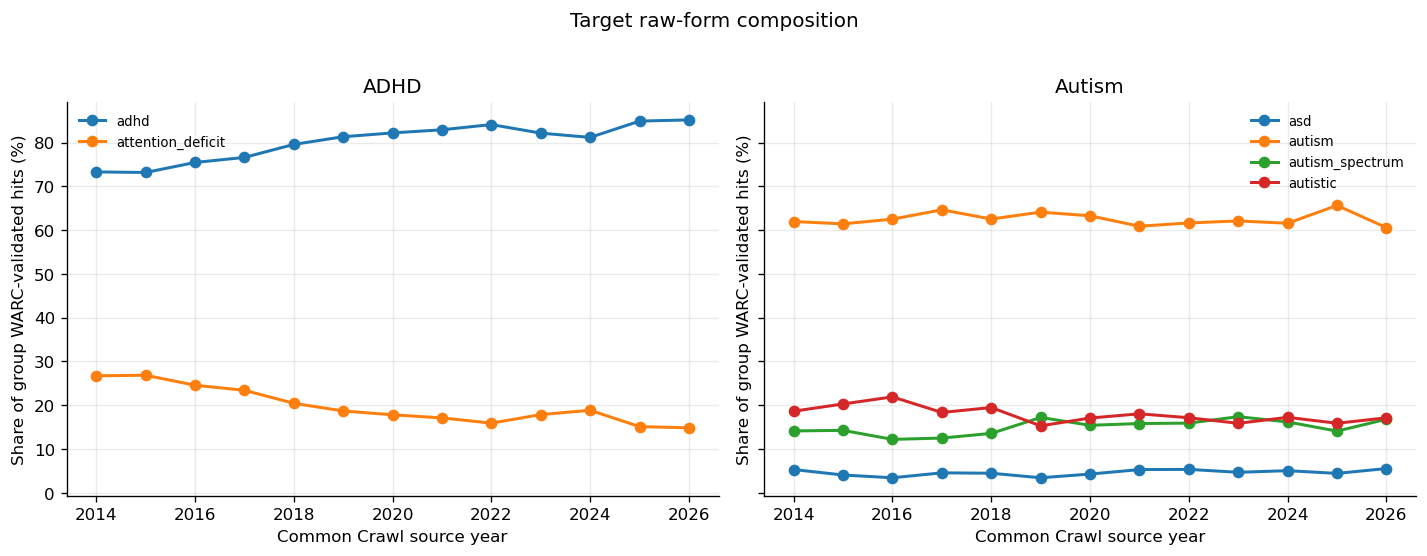

In [7]:
raw_form_year = matched_target_rows[[
    "year", "term_group", "matched_term", "candidate_hits", "validated_hits_wet", "validated_hits_warc",
    "primary_salience_per_million_tokens", "warc_over_wet_validation_rate",
]].copy()
raw_form_year["analysis_unit"] = raw_form_year["term_group"].map({"adhd": "ADHD", "autism": "Autism"})
raw_form_year["warc_share_within_group"] = raw_form_year["validated_hits_warc"] / raw_form_year.groupby(["year", "analysis_unit"])["validated_hits_warc"].transform("sum")
raw_form_year = raw_form_year.sort_values(["analysis_unit", "matched_term", "year"])
raw_form_year.to_csv(OUTPUT_DIR / "salience_raw_form_year.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, unit in zip(axes, TARGET_UNITS):
    frame = raw_form_year.loc[raw_form_year["analysis_unit"].eq(unit)]
    for raw_form, raw_frame in frame.groupby("matched_term"):
        axis.plot(raw_frame["year"], 100 * raw_frame["warc_share_within_group"], marker="o", linewidth=1.8, label=raw_form)
    axis.set_title(unit)
    axis.set_xlabel("Common Crawl source year")
    axis.set_ylabel("Share of group WARC-validated hits (%)")
    axis.set_xticks(EXPECTED_YEARS[::2])
    axis.grid(alpha=0.25)
    axis.legend(frameon=False, fontsize=8)
figure.suptitle("Target raw-form composition", y=1.02)
figure.tight_layout()
save_figure(figure, "lsc_salience_raw_form_composition")
plt.show()

## Publication-Year Diagnostics

Salience deliberately uses Common Crawl source year because the denominator is the annual WET scan. Publication-year status nevertheless shows how much WARC-validated target material predates the 2014 analysis window or lacks a parseable publication year.

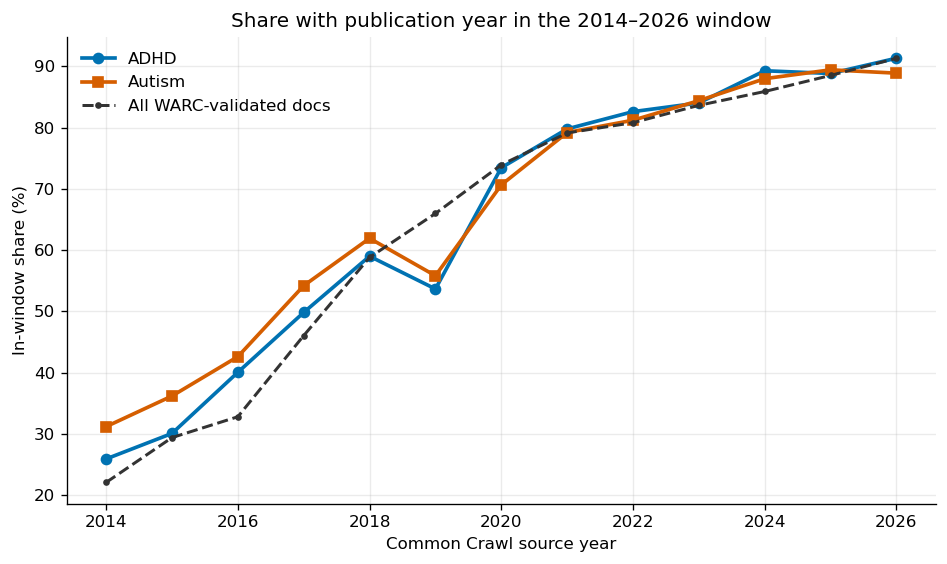

publication_year_status  before_window  in_window  missing_or_unparseable
year analysis_unit                                                       
2014 ADHD                        0.723      0.259                   0.018
     Autism                      0.668      0.312                   0.020
2015 ADHD                        0.649      0.301                   0.050
     Autism                      0.621      0.362                   0.017
2016 ADHD                        0.590      0.400                   0.009
     Autism                      0.555      0.426                   0.020
2017 ADHD                        0.480      0.498                   0.022
     Autism                      0.440      0.542                   0.018
2018 ADHD                        0.380      0.590                   0.030
     Autism                      0.361      0.619                   0.020
2019 ADHD                        0.362      0.536                   0.101
     Autism                      0.373      0.558                   0.069
2020 ADHD                        0.242      0.734                   0.023
     Autism                      0.274      0.706                   0.020
2021 ADHD                        0.186      0.798                   0.016
     Autism                      0.188      0.792                   0.020
2022 ADHD                        0.156      0.826                   0.018
     Autism                      0.175      0.812                   0.013
2023 ADHD                        0.149      0.840                   0.011
     Autism                      0.144      0.844                   0.012
2024 ADHD                        0.096      0.893                   0.011
     Autism                      0.110      0.880                   0.010
2025 ADHD                        0.098      0.888                   0.014
     Autism                      0.096      0.894                   0.010
2026 ADHD                        0.076      0.913                   0.011
     Autism                      0.101      0.889                   0.011

In [8]:
term_publication = publication_diagnostics.loc[publication_diagnostics["diagnostic_level"].eq("term")].copy()
term_publication["analysis_unit"] = np.where(
    term_publication["term_role"].eq("target"),
    term_publication["term_group"].map({"adhd": "ADHD", "autism": "Autism"}),
    term_publication["matched_term"],
)
publication_unit_status = term_publication.loc[term_publication["analysis_unit"].isin(ANALYSIS_UNITS)].groupby(
    ["year", "analysis_unit", "publication_year_status"], as_index=False
)["validated_hits_warc"].sum()
publication_unit_status["status_share"] = publication_unit_status["validated_hits_warc"] / publication_unit_status.groupby(["year", "analysis_unit"])["validated_hits_warc"].transform("sum")
publication_unit_status.to_csv(OUTPUT_DIR / "salience_publication_year_status.csv", index=False)

document_publication = publication_diagnostics.loc[publication_diagnostics["diagnostic_level"].eq("document")].groupby(
    ["year", "publication_year_status"], as_index=False
)[["input_docs", "fetch_success_docs", "warc_validated_docs"]].sum()
document_publication["warc_status_share"] = document_publication["warc_validated_docs"] / document_publication.groupby("year")["warc_validated_docs"].transform("sum")
document_publication.to_csv(OUTPUT_DIR / "salience_publication_year_document_status.csv", index=False)

figure, axis = plt.subplots(figsize=(8, 4.8))
for unit in TARGET_UNITS:
    frame = publication_unit_status.loc[
        publication_unit_status["analysis_unit"].eq(unit) & publication_unit_status["publication_year_status"].eq("in_window")
    ]
    axis.plot(frame["year"], 100 * frame["status_share"], color=COLOURS[unit], marker=MARKERS[unit], linewidth=2.2, label=unit)
all_in_window = document_publication.loc[document_publication["publication_year_status"].eq("in_window")]
axis.plot(all_in_window["year"], 100 * all_in_window["warc_status_share"], color="#333333", marker=".", linestyle="--", linewidth=1.8, label="All WARC-validated docs")
axis.set_title("Share with publication year in the 2014–2026 window")
axis.set_xlabel("Common Crawl source year")
axis.set_ylabel("In-window share (%)")
axis.set_xticks(EXPECTED_YEARS[::2])
axis.grid(alpha=0.25)
axis.legend(frameon=False)
figure.tight_layout()
save_figure(figure, "lsc_salience_publication_year_status")
plt.show()

display(publication_unit_status.loc[publication_unit_status["analysis_unit"].isin(TARGET_UNITS)].pivot_table(index=["year", "analysis_unit"], columns="publication_year_status", values="status_share").round(3))

## Interpretation Handoff

The primary output characterises prominence within the sampled Common Crawl trend slices, not population prevalence or public concern. WARC validation changes both the level and, potentially, the shape of the series; retention and publication-year composition must therefore accompany substantive interpretation. Frame composition cannot be assessed until the supervised classifier is complete.

In [9]:
target_summary = trend_summary.loc[trend_summary["analysis_role"].eq("target"), [
    "analysis_unit", "early_2014_2016_mean", "late_2024_2026_mean", "early_to_late_pct_change",
    "linear_slope_per_year", "spearman_year_rate", "mean_warc_over_wet_validation_rate",
]].copy()

print("Primary target trajectory summary:")
display(target_summary.round(4))
print("Saved analysis tables:")
for path in sorted(OUTPUT_DIR.glob("salience_*.csv")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")
print("Saved figures:")
for path in sorted(FIGURE_DIR.glob("lsc_salience_*")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")

Primary target trajectory summary:


,analysis_unit,early_2014_2016_mean,late_2024_2026_mean,early_to_late_pct_change,linear_slope_per_year,spearman_year_rate,mean_warc_over_wet_validation_rate
3,ADHD,0.3429,0.4113,19.9636,0.0073,0.4615,0.3215
4,Autism,0.9819,0.7453,-24.0988,-0.0228,-0.5604,0.3618


Saved analysis tables:
- data/processed/lsc/salience/salience_audit_checks.csv
- data/processed/lsc/salience/salience_denominator_audit.csv
- data/processed/lsc/salience/salience_publication_year_document_status.csv
- data/processed/lsc/salience/salience_publication_year_status.csv
- data/processed/lsc/salience/salience_raw_form_year.csv
- data/processed/lsc/salience/salience_trend_summary.csv
- data/processed/lsc/salience/salience_unit_year.csv
Saved figures:
- reports/figures/lsc/salience/lsc_salience_primary_trajectories.pdf
- reports/figures/lsc/salience/lsc_salience_primary_trajectories.png
- reports/figures/lsc/salience/lsc_salience_publication_year_status.pdf
- reports/figures/lsc/salience/lsc_salience_publication_year_status.png
- reports/figures/lsc/salience/lsc_salience_raw_form_composition.pdf
- reports/figures/lsc/salience/lsc_salience_raw_form_composition.png
- reports/figures/lsc/salience/lsc_salience_retention.pdf
- reports/figures/lsc/salience/lsc_salience_retention.png